# 1. Start to Finish Regression Problem
In this Notebook, we will work on different Regression Problems using Scikit-Learn.

In [496]:
# Dowload some libraries
from pathlib import Path
import pandas as pd, tarfile, urllib.request

import matplotlib.pyplot as plt, numpy as np, pandas as pd, seaborn as sns

## Get the Data
First, let's download the dataset of housing data.

In [497]:
# Download the data
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

## Inspect the Data

In [498]:
# Inspect the dataset
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [499]:
# Get a first overview of the structure
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [500]:
# Some of the values are missing in 'total_bedrooms'
housing_full.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [501]:
# Count how many districs belong to each category
housing_full['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [502]:
# Inspect the numerical features
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


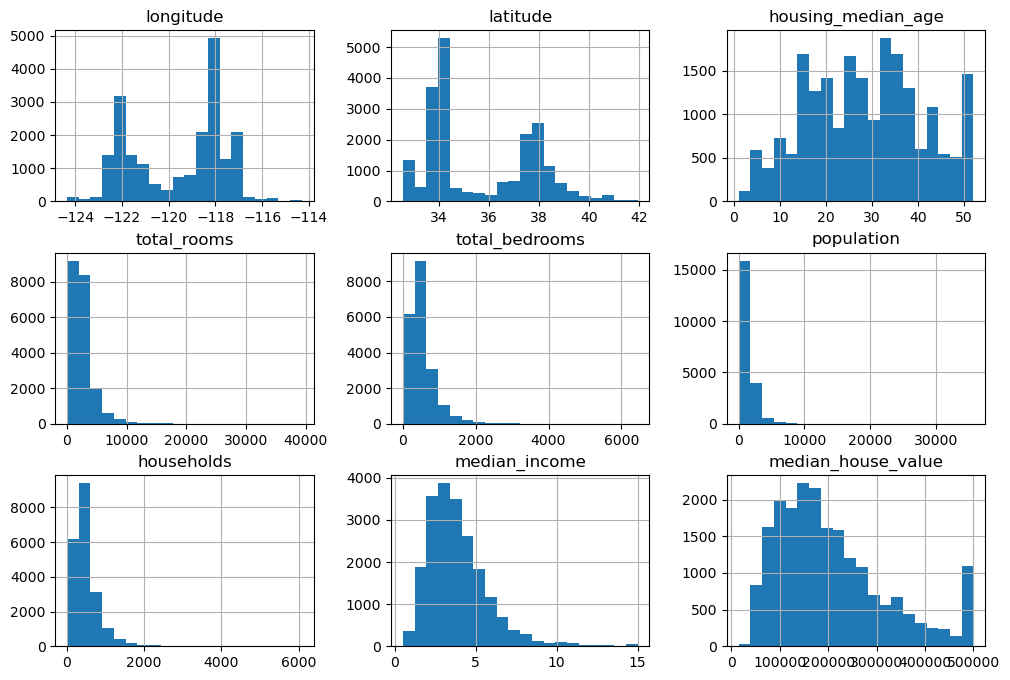

In [503]:
# Another good way is to plot histograms of the numerical attributes
housing_full.select_dtypes('number').hist(figsize=(12,8), bins = 20)
plt.show()

Looking at the histogram we see the following:
1. Median income does not look like it is expressed in US dollars, it has been capped at 15 (15k USD)
2. Housing median age and median house value were also capped. You can now: Collect proper labels for the districts whose labels were capped or remove those districts from the training set (and also test set, since your system should not be evaluated poorly if it predicts values beyond $500k)
3. Attributes have very different scales
4. Many histograms are skewed right

## Create a Test Set
Create a test set to avoid data snooping or a high generalization error. The best solution is to use Sckikit-Learns train_test_split() function.

Purely random sampling:

In [504]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing_full, test_size=0.2, random_state=42)

Stratified sampling to consider underrepresented ratio's:


In [505]:
# Create a income category using pd.cut
housing_full['income_cat'] = pd.cut(
    housing_full['median_income'],
    bins = [0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1,2,3,4,5])

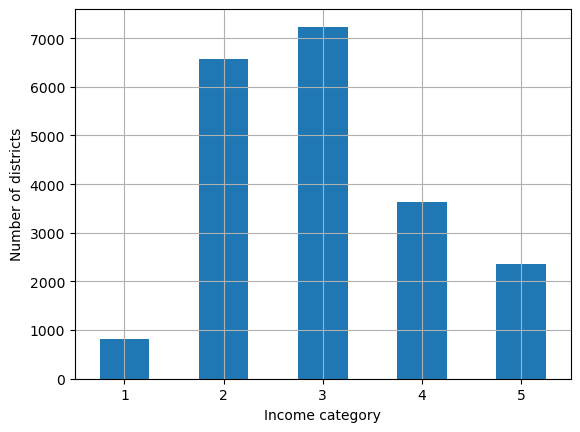

In [506]:
cat_counts = housing_full['income_cat'].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [507]:
# Using stratified sampling
strat_test_set, strat_train_set = train_test_split(housing_full, 
                                                   test_size=0.2, 
                                                   stratify=housing_full['income_cat'], 
                                                   random_state=42)

# Test if it worked
strat_test_set['income_cat'].value_counts() / len(strat_test_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [508]:
# Drop the income_cat column
for set_ in (strat_test_set, strat_train_set):
    set_.drop("income_cat", axis=1, inplace=True)

## Data Exploration and Visualisation to Gain Insights
Every EDA should use a copy of the dataset.

In [509]:
housing = strat_train_set.copy()

### Visualisation the Geographical Data

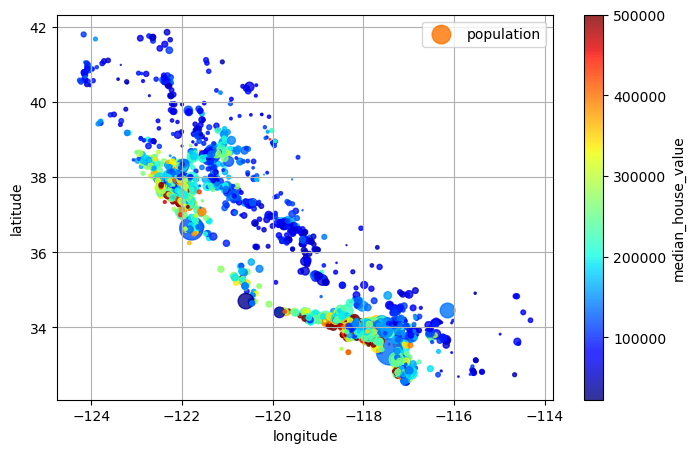

In [510]:
housing.plot(kind='scatter',x='longitude', y='latitude', grid = True, alpha = 0.8,
             s = housing['population']/ 100, label='population',
             c = 'median_house_value', cmap = 'jet', colorbar = True,
             legend = True, sharex = False, figsize = (8,5))
plt.show()

### Look for Correlation
Compute the Standard Correlation Coefficient (Pearsons R):

In [511]:
# Select only numeric variables
corr_matrix = housing.corr(numeric_only=True)

# Look at each attribute
corr_matrix['median_house_value'].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.687091
total_rooms           0.121070
housing_median_age    0.118976
households            0.043549
total_bedrooms        0.029600
longitude            -0.026768
population           -0.040286
latitude             -0.162087
Name: median_house_value, dtype: float64

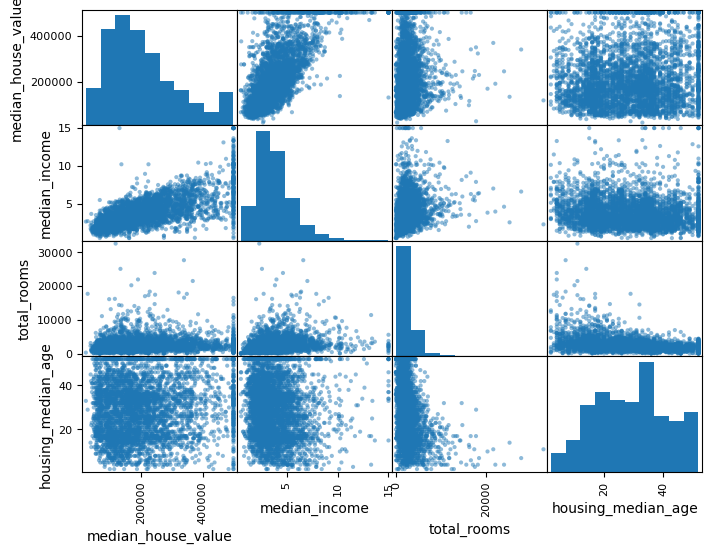

In [512]:
# Display the correlation graphically
from pandas.plotting import scatter_matrix
attributes = ["median_house_value","median_income","total_rooms","housing_median_age"] # just a few
scatter_matrix(housing[attributes], figsize=(8,6))
plt.show()

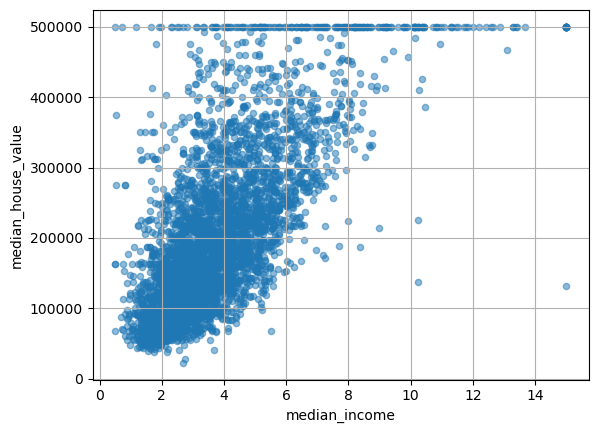

In [513]:
# We zoom in on the median_house_value vs median_income variable
housing.plot(kind='scatter',x='median_income',y='median_house_value',grid=True,alpha=0.5)
plt.show()

We can see that the median_house_value is capped at $USD500k. We may need to remove those districts to prevent the algorithm to learn those data patterns.

### Experiement with Attribute Combinations

In [514]:
housing['rooms_per_house'] = housing['total_rooms'] / housing['households']
housing['bedrooms_ratio'] = housing['total_bedrooms'] / housing['total_rooms']
housing['people_per_house'] = housing['population'] / housing['households']

# Look at the correlation again
corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687091
rooms_per_house       0.198322
total_rooms           0.121070
housing_median_age    0.118976
households            0.043549
total_bedrooms        0.029600
people_per_house     -0.025974
longitude            -0.026768
population           -0.040286
latitude             -0.162087
bedrooms_ratio       -0.254506
Name: median_house_value, dtype: float64

The new features have a greater linear relationship with the target variable. Make sure new features are not too linearly correlated with existing features: collinearity can cause issues.

## Prepare the Data for Machine Learning Algorithms
First, let's copy the clean training set again and let's also separate the predictors and the labels.

In [515]:
housing = strat_train_set.drop('median_house_value',axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

### Clean the Data
Fix missing features, there are three options:
1. Get rid of the corresponding districts
2. Get rid of the whole attribute
3. Set the missing values to some value (zero, the mean, the median, etc) - Imputation

In [516]:
# All three options are below
housing.dropna(subset=['total_bedrooms']) # Option 1 - `inplace = True` to save it
housing.drop('total_bedrooms',axis=1) # Option 2 - `inplace = True` to save it

# Option 3
median = housing['total_bedrooms'].median()
housing['total_bedrooms'].fillna(median) # We will not save this - since imputation using SimpleImputer is better

3905      357.0
16821     265.0
2900     1750.0
7193      423.0
13928     515.0
          ...  
12369     597.0
8707      459.0
16634     147.0
9779      383.0
3455      389.0
Name: total_bedrooms, Length: 4128, dtype: float64

In [517]:
# Let's use SimpleImputer instead
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

# Results are in statistics_
imputer.statistics_

array([-118.46  ,   34.23  ,   29.    , 2137.5   ,  438.    , 1163.    ,
        412.5   ,    3.5269])

In [518]:
# To show it is correct
print(imputer.statistics_)
print(housing_num.median().values)

[-118.46     34.23     29.     2137.5     438.     1163.      412.5
    3.5269]
[-118.46     34.23     29.     2137.5     438.     1163.      412.5
    3.5269]


Now we can use this `trained` imputer to transfor the training set by replacing missing values with the learned medians:

In [519]:
X = imputer.transform(housing_num)

Scikit-Learn transformers output Numpy arrays. So, the output of `imputer.transform(housing_num)` is a Numpy array. We have to wrap X in a DataFrame to recover the column names and index:

In [520]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
3905,-121.95,37.11,21.0,2387.0,357.0,913.0,341.0,7.7360
16821,-118.01,33.89,36.0,1589.0,265.0,804.0,272.0,4.6354
2900,-118.18,33.74,30.0,5915.0,1750.0,2136.0,1503.0,4.0968
7193,-122.48,37.74,52.0,2166.0,423.0,1072.0,370.0,4.1310
13928,-122.39,37.78,5.0,1405.0,515.0,725.0,392.0,3.6037


### Handling Text and Categorical Attributes

In [521]:
# Have a look
housing_cat = housing[['ocean_proximity']]
housing_cat.head(8)

,ocean_proximity
3905,<1H OCEAN
16821,<1H OCEAN
2900,NEAR OCEAN
7193,NEAR OCEAN
13928,NEAR BAY
6523,<1H OCEAN
33,NEAR BAY
15996,<1H OCEAN


For our model to understand the data, we must first convert these categories from text to numbers:

In [522]:
# Using Scikit-Learns OrdinalEncoder class
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:8]

array([[0.],
       [0.],
       [4.],
       [4.],
       [3.],
       [0.],
       [3.],
       [0.]])

In [523]:
# Get the list of categories
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

<b>ISSUE</b> with OrdinalEncoder - The ML algorithm will give the order an ordinal meaning.

Preferred Sklearn encoding class is `OneHotEncoder`:

In [524]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4128 stored elements and shape (4128, 5)>

By default the output is a Sparse matrix. To fix this:

In [525]:
# Alternatively use `sparse_output = False`
'''
cat_encoder2 = OneHotEncoder(sparse_output=False, handle_unknown="ignore") # it will represent unknown categories with zeros
housing_cat_1hot_2 = cat_encoder2.fit_transform(housing_cat)
housing_cat_1hot_2
'''

housing_cat_1hot.toarray()

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [526]:
# Column names can be accessed with `feature_names_in`
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

### Feature Scaling and Transformation

#### Min-Max Scaling
Values are shifted and rescaled so that they end up ranging from 0 to 1.

In [527]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range = (-1,1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)
housing_num_min_max_scaled[:2]

array([[-0.53567839, -0.0193133 , -0.24      , -0.85430464, -0.89009624,
        -0.94909886, -0.8887975 , -0.00193101],
       [ 0.25628141, -0.71030043,  0.36      , -0.90323767, -0.9186588 ,
        -0.95520924, -0.9114986 , -0.42959407]])

#### Standardization
First, it subtracts the mean value (so standard values have a zero mean), then it divides the result by the standard deviation (so standardized values have a SD equal to 1).

It is much less affected by outliers.

In [528]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)
housing_num_std_scaled[:2]

array([[-1.18804209,  0.69962912, -0.62700415, -0.10808741, -0.42926386,
        -0.40276867, -0.41227995,  2.00117828],
       [ 0.76723335, -0.8005624 ,  0.56519904, -0.47637177, -0.65294066,
        -0.48845945, -0.59377634,  0.39551595]])

### Transformation
Since our data is skewed, we will need to transform it so it passes the assumption of Normality.

In [529]:
# Using a custom transformer - Logarithmic transformation
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func = np.exp)
log_pop = log_transformer.transform(housing[['population']])
log_pop.head()

,population
3905,6.816736
16821,6.689599
2900,7.666690
7193,6.977281
13928,6.586172


In [530]:
# RBF-Kernel - Similarity transformation from Y = 35
from sklearn.metrics.pairwise import rbf_kernel

rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.]], gamma = 0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])
age_simil_35[:5]

array([[3.07487988e-09],
       [9.04837418e-01],
       [8.20849986e-02],
       [2.81118530e-13],
       [8.19401262e-40]])

### Customs Transformer
Below we are creating a Standard Scaler from scratch:

In [531]:
# Packages
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean = True):
        self.with_mean = with_mean
    
    def fit(self, X, y=None): # y is required even though we don't use it
        X = check_array(X) # checks that X is an array with finite float values
        self.mean_ = X.mean(axis = 0)
        self.scale_ = X.std(axis = 0)
        self.n_features_in_ = X.shape[1] # every estimator stores this in fit()
        return self # always return self!
    
    def transform(self, X):
        check_is_fitted(self) # looks for learned attributes (with trailing _)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

Let's also create a custom transformer that uses a KMeans clusterer in the `fit()` method to identify the main clusters in the training data, and then uses `rbf_kernel()` in the `transform()` method to measure how similar each sample is to each cluster center:

In [532]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters = 10, gamma = 1.0, random_state = None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
        
    def fit(self, X, y=None, sample_weight = None):
        self.kmeans_ = KMeans(self.n_clusters, random_state = self.random_state)
        self.kmeans_.fit(X, sample_weight = sample_weight)
        return self # always return self!
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma = self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]
        

In [533]:
# Let's use the new code
cluster_simil = ClusterSimilarity(n_clusters=10, gamma =1., random_state=42)
similarities = cluster_simil.fit_transform(housing[['latitude','longitude']])
# Let's look at the results
similarities[:3].round(2)

array([[0.46, 0.  , 0.  , 0.89, 0.  , 0.  , 0.  , 0.  , 0.  , 0.07],
       [0.  , 0.93, 0.  , 0.  , 0.  , 0.14, 0.67, 0.01, 0.  , 0.  ],
       [0.  , 0.92, 0.  , 0.  , 0.  , 0.12, 0.5 , 0.01, 0.  , 0.  ]])

### Transformation Pipelines
Ensures the data transformation steps are executed in the right order.

In [534]:
from sklearn.pipeline import Pipeline
import sklearn
# Optional
sklearn.set_config(display='diagram')

num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy = "median")),
    ('standardise', StandardScaler())
])

# Alternatively
from sklearn.pipeline import make_pipeline
num_pipeline = make_pipeline(SimpleImputer(strategy = "median"), StandardScaler())

In [535]:
# Call the fit_transform method
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.19,  0.7 , -0.63, -0.11, -0.43, -0.4 , -0.41,  2.  ],
       [ 0.77, -0.8 ,  0.57, -0.48, -0.65, -0.49, -0.59,  0.4 ]])

In [536]:
# Recover the DataFrame
df_housing_num_prepared = pd.DataFrame(housing_num_prepared, 
                                       columns = num_pipeline.get_feature_names_out(),
                                       index = housing_num.index)
df_housing_num_prepared.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
3905,-1.188042,0.699629,-0.627004,-0.108087,-0.428991,-0.402769,-0.412280,2.001178
16821,0.767233,-0.800562,0.565199,-0.476372,-0.653675,-0.488459,-0.593776,0.395516
2900,0.682869,-0.870447,0.088318,1.520117,2.973013,0.558698,2.644224,0.116599
7193,-1.451061,0.993145,1.836882,-0.210081,-0.267805,-0.277770,-0.335999,0.134310
13928,-1.406398,1.011781,-1.898688,-0.561289,-0.043122,-0.550566,-0.278130,-0.138755


#### ColumnTransformer
The below pipeline will transform numerical and categorical features:

In [537]:
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer

num_attribs = make_column_selector(dtype_include=np.number)
cat_attribs = make_column_selector(dtype_include=object)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy = "most_frequent"),
    OneHotEncoder(handle_unknown = "ignore"))

# num_pipeline

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

housing_prepared = preprocessing.fit_transform(housing)
housing_prepared[:2]

array([[-1.18804209,  0.69962912, -0.62700415, -0.10808741, -0.42899131,
        -0.40276867, -0.41227995,  2.00117828,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.76723335, -0.8005624 ,  0.56519904, -0.47637177, -0.65367499,
        -0.48845945, -0.59377634,  0.39551595,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ]])

Let's create one final pipeline that will:
1. Impute missing values in numerical features with median, NaN of categorical features with mode
2. The categorical feature will be one-hot encoded
3. A few ratio features will be computed and added
4. A few cluster similarity features will also be added
5. Feature with a long tail will be replaced by their logarithm
6. All numerical features will be standardised

In [538]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age

## Model Training and Fine-Tuning
### Model Training Using Cross-Validation
`cross_val_score()`: Evaluates how well a model performs using cross-validation and returns performance scores - not predictions. _How good is this model on average across folds?_

`cross_val_predict()`: Returns cross-validated predictions for every data point. _What would this model predict for each point if it never saw that point during training?_

#### Decision Tree Regressor

In [539]:
# Try a DecisionTreeRegressor - capable of finding nonlinear relationships
from sklearn.tree import DecisionTreeRegressor
tree_reg = make_pipeline(
    preprocessing,
    DecisionTreeRegressor(random_state=42))

# Using cross_val_score to estimate generalisation performance
from sklearn.model_selection import cross_val_score
tree_rmses = -cross_val_score(tree_reg, housing, housing_labels, # needs to be negative since,
                              scoring = "neg_root_mean_squared_error", cv=10) # outputs a utility function

In [540]:
# Look at the results
pd.Series(tree_rmses).describe()

count       10.000000
mean     75696.163796
std       3992.504395
min      68980.344434
25%      74188.455905
50%      74910.035051
75%      77294.436030
max      82437.713466
dtype: float64

#### Random Forest Regressor

In [541]:
# Try RandomForestRegressor - trains many decision trees on random subsets of the features, then avg predictions
from sklearn.ensemble import RandomForestRegressor
forest_reg = make_pipeline(
    preprocessing,
    RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
                                scoring = "neg_root_mean_squared_error", cv = 10, n_jobs=-1)
pd.Series(forest_rmses).describe()

count       10.000000
mean     52545.728421
std       2868.277396
min      48463.675683
25%      51101.651152
50%      51890.228417
75%      53733.805341
max      58559.113523
dtype: float64

The goal is to shortlist a few (two to five) processing models.

### Fine-Tune Your Model
#### GridSearch
Tries every possible combination of the hyperparameters you specify. Each combination is evaluated using cross-validation. Doesn't scale well with many parameters.

In [542]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(housing, housing_labels)

# Best parameters
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [543]:
# Access the results 
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by='mean_test_score', ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,0.997410,0.006986,0.026274,0.002943,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-49054.608812,-50686.543130,-51270.039495,-50337.063813,937.598039,1
13,1.209723,0.031294,0.024595,0.000513,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-49928.558582,-50905.577093,-51423.954989,-50752.696888,619.990253,2
6,0.693190,0.005801,0.028450,0.001515,10,4,"{'preprocessing__geo__n_clusters': 10, 'random...",-50086.724549,-51612.220583,-51706.350999,-51135.098711,742.307852,3
14,1.327013,0.030925,0.024215,0.000369,15,10,"{'preprocessing__geo__n_clusters': 15, 'random...",-50323.114414,-51943.855304,-51331.798584,-51199.589434,668.236336,4
7,1.029450,0.046525,0.034206,0.005523,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-50362.035044,-52076.111658,-51166.887777,-51201.678160,700.201132,5


#### RandomizedSearch
Randomly samples combinations from the hyperparameter space.
1. You specify distributions or lists
2. It tries a fixed number of random combinations (n_iter)
3. Uses CV to evaluate each one

- Much faster for large search spaces
- Often finds near-optimal solutions
- Better for continuous parameters

CONS: No guarantee you tested the absolute best combo.

In [544]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)

rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x329252c50>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x329af8370>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [545]:
### Analysing the Best Models and Their Errors
final_model = rnd_search.best_estimator_ # incl. preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.07, 0.06, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.01, 0.02,
       0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.03, 0.01, 0.01, 0.  , 0.01, 0.01, 0.02,
       0.01, 0.01, 0.02, 0.02, 0.01, 0.02, 0.01, 0.02, 0.01, 0.01, 0.02,
       0.01, 0.01, 0.01, 0.01, 0.02, 0.02, 0.02, 0.01, 0.01, 0.  , 0.07,
       0.  , 0.  , 0.  , 0.01])

In [546]:
# Let's sort them in descending order and display them next to their corresponding attribute names
sorted(zip(feature_importances, final_model['preprocessing'].get_feature_names_out()), reverse=True)[:5]

[(np.float64(0.188548503808745), 'log__median_income'),
 (np.float64(0.07375296938289282), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.0718170008332404), 'bedrooms__ratio'),
 (np.float64(0.056554847463841505), 'rooms_per_house__ratio'),
 (np.float64(0.04527750999484971), 'people_per_house__ratio')]

We may want to try dropping some of the less useful features.

## Model Evaluation on the Test Set
After tweaking the model, we are ready to evaluate the final model on the test set. Just get the predictors and the labels from your test set and run your `final_model` to transform the data and make predictions, then evaluate these predictions:

In [547]:
from sklearn.metrics import root_mean_squared_error

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

45710.2447224823


Compute a 95% _confidence interval_ for the generalization error using `scipy.stats.bootstrap()`.

In [548]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse, confidence_level=confidence, random_state = 42)

# Result
rmse_lower, rmse_upper = boot_result.confidence_interval
print(rmse_lower)
print(rmse_upper)

44693.64841301732
46807.03532349502


### Launch, Monitor, and Maintain Your System
The most basic way to save the model to your production environment:

In [549]:
import joblib
joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

# Some Exercises
## 1. Support Vector Regressor

Let's train a support vector machine regressor. First, let's try GridSearchCV to identify the best parameter combination.

In [556]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# GridSearch
svr_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("svr", SVR())
    ])

param_svr = [
        {'svr__kernel': ['linear'], 'svr__C': [10., 30., 100., 300., 1000.,
                                               3000., 10000., 30000.0]},
        {'svr__kernel': ['rbf'], 'svr__C': [1.0, 3.0, 10., 30., 100., 300.,
                                            1000.0],
         'svr__gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]},
    ]

grid_search_svr = GridSearchCV(svr_pipeline, param_svr, cv=3, n_jobs=-1,
                               scoring='neg_root_mean_squared_error')
grid_search_svr.fit(housing[:5000], housing_labels[:5000])

grid_search_svr.best_params_

{'svr__C': 3000.0, 'svr__kernel': 'linear'}

In [557]:
# Let's try a support vector regressor
svr_grid_search_rmse = -grid_search_svr.best_score_
svr_grid_search_rmse

np.float64(82291.7276706498)

## 2. Replace GridSearchCV with RandomizedSearchCV

In [558]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, loguniform

svr_params = {
        'svr__kernel': ['linear', 'rbf'],
        'svr__C': loguniform(20, 200_000),
        'svr__gamma': expon(scale=1.0),
    }

rnd_svr = RandomizedSearchCV(
    svr_pipeline, param_distributions=svr_params, n_iter=50, cv=3, n_jobs=-1,
    scoring='neg_root_mean_squared_error', random_state=42)

rnd_svr.fit(housing[:5000], housing_labels[:5000])
rnd_svr.best_params_

{'svr__C': np.float64(157055.10989448498),
 'svr__gamma': np.float64(0.26497040005002437),
 'svr__kernel': 'rbf'}

In [560]:
# Performance
svr_rnd_search_rmse = -rnd_svr.best_score_
svr_rnd_search_rmse

np.float64(58419.173546136466)

## 3. Adding a SelectFromModel transformer
`sklearn.feature_selection.SelectFromModel`: Takes a model (estimator) that has feature importance information:
1. `feature_importance_` (for tree-based models, e.g. RandomForest, GradientBoosting)
2. `coef_` (for linear models, LinearRegression, LogisticRegresion, LinearSVC)

- Selects features whose importance or absolute coefficient is above a certain threshold
- Can be used before or as part of a pipeline to reduce dimensionality and remove irrelevant features.